In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000  # top 10k most frequent words
MAX_LEN = 200       # max review length (pad/truncate)

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 25000
Test samples: 25000


In [ ]:
X_train_lstm = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_lstm  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train_lstm = np.array(y_train)
y_test_lstm  = np.array(y_test)

print("X_train shape:", X_train_lstm.shape)
print("X_test shape: ", X_test_lstm.shape)

X_train shape: (25000, 200)
X_test shape:  (25000, 200)


In [ ]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 304ms/step - accuracy: 0.5319 - loss: 0.6906 - val_accuracy: 0.5838 - val_loss: 0.6778
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.5964 - loss: 0.6685 - val_accuracy: 0.6546 - val_loss: 0.6470
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 304ms/step - accuracy: 0.5932 - loss: 0.6547 - val_accuracy: 0.5724 - val_loss: 0.6730
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 306ms/step - accuracy: 0.6507 - loss: 0.5997 - val_accuracy: 0.6678 - val_loss: 0.6247
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 303ms/step - accuracy: 0.6963 - loss: 0.5732 - val_accuracy: 0.5488 - val_loss: 0.6782


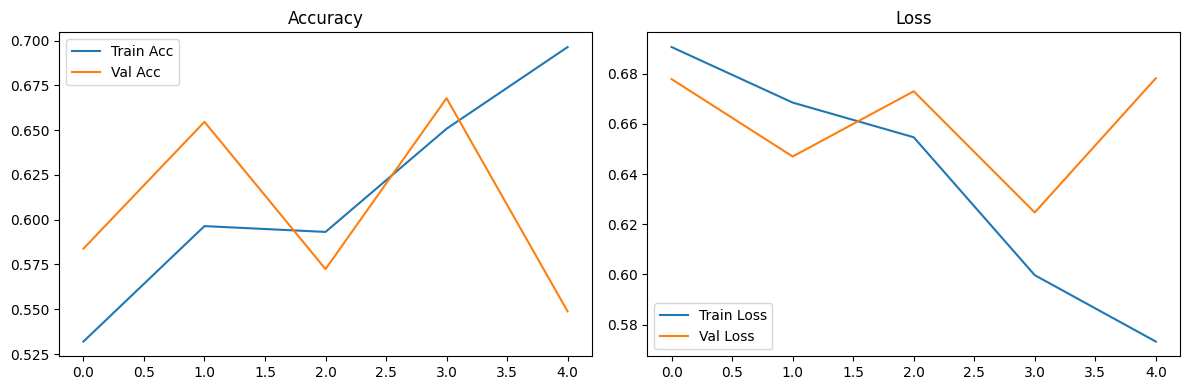

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
loss, acc = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

y_pred = model.predict(X_test_lstm)
y_pred_classes = (y_pred > 0.5).astype("int32")

mapping = {1: 'positive', 0: 'negative'}
print("\nTop 10 predictions:")
for i in range(10):
    actual    = mapping[y_test_lstm[i]]
    predicted = mapping[y_pred_classes[i][0]]
    print(f"Sample {i+1} --> Actual: {actual}, Predicted: {predicted}")

Test Accuracy: 0.5435
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step

Top 10 predictions:
Sample 1 --> Actual: negative, Predicted: negative
Sample 2 --> Actual: positive, Predicted: positive
Sample 3 --> Actual: positive, Predicted: positive
Sample 4 --> Actual: negative, Predicted: negative
Sample 5 --> Actual: positive, Predicted: negative
Sample 6 --> Actual: positive, Predicted: negative
Sample 7 --> Actual: positive, Predicted: positive
Sample 8 --> Actual: negative, Predicted: negative
Sample 9 --> Actual: negative, Predicted: negative
Sample 10 --> Actual: positive, Predicted: positive


SENTIMENT ANALYSIS USING RNN (IMDB)

1. WHAT IS THIS PROJECT?
Topic: Classify movie reviews from IMDB as Positive (1) or Negative (0) using a Recurrent Neural Network (LSTM).

•	Type of problem: Binary Classification (2 outputs: 0 or 1)
•	Field: Natural Language Processing (NLP)
•	Model used: LSTM (a type of RNN)
•	Dataset: Built-in Keras IMDB dataset — 50,000 reviews

One-line definition → Sentiment Analysis = Teaching a computer to read text and decide if the opinion is positive or negative.

2. IMDB DATASET — KEY FACTS
Property	Value
Total reviews	50,000
Training set	25,000 reviews
Test set	25,000 reviews
Balance	50% positive, 50% negative — perfectly balanced
Format	Pre-tokenized integers (each word → its frequency rank)
Vocabulary limit	Top 10,000 most frequent words (num_words=10000)
Sequence length	Padded/truncated to 200 words (maxlen=200)
Labels	1 = positive, 0 = negative

"the movie was great" → stored as [1, 17, 6, 92] — each number is a word's rank in frequency. Word #1 = most common word ("the"), etc.

Why limit to 10,000 words? Rare words add noise without meaning. We keep only the most common 10k words; the rest are treated as 'unknown'.

Why pad sequences? All inputs must be the same size. Reviews shorter than 200 get zeros added at the end. Longer ones are cut off.

3. RNN & LSTM — CORE CONCEPT
3a. What is an RNN?
RNN = Recurrent Neural Network. Processes input one word at a time and maintains a hidden state (memory) of what it has seen so far. Unlike regular neural networks which ignore order, RNNs understand sequence.

Analogy: Reading a sentence word by word and updating your understanding after each word. By the end, you've understood the full context.

3b. Problem with basic RNN — Vanishing Gradient
When a sequence is long, gradients (error signals) shrink as they travel back through time. By the time they reach early words, the signal is near-zero. So the model forgets the beginning of long reviews.

Analogy: Reading a 500-page book but completely forgetting Chapter 1 by the time you reach the end. The model cannot connect early clues to final conclusions.

3c. LSTM — The Solution
LSTM = Long Short-Term Memory. A smarter RNN with a special cell state (long-term memory) controlled by 3 gates:

Gate	What it does	Analogy
Forget gate	Decides what old info to throw away	Erasing useless sticky notes
Input gate	Decides what new info to store	Highlighting new important points
Output gate	Decides what to output at this step	Choosing what to say based on notes

Key point: LSTM solves vanishing gradient by allowing gradients to flow unchanged through the cell state over long sequences. That's why it remembers context from the start of a long review.

3d. RNN vs LSTM — Quick Comparison
RNN
Simple structure
Fast to train
Forgets long sequences
Not good for long text	LSTM
Gated structure (3 gates)
Slightly slower
Remembers long-range info
Standard choice for NLP

4. MODEL ARCHITECTURE
Our model has 3 layers: Embedding → LSTM → Dense

Layer	Parameters	Purpose
Embedding	vocab=10k, output=64, len=200	Converts word IDs → 64-dim vectors. Similar words get similar vectors.
LSTM	64 units, dropout=0.2	Reads sequence of 200 vectors, outputs 1 summary vector of the review.
Dense	1 unit, sigmoid	Converts LSTM output → probability (0 to 1). >0.5 = positive.

Embedding Layer — in detail
Input shape: (batch, 200) — 200 word IDs per review
Output shape: (batch, 200, 64) — each word ID becomes a 64-number vector
These vectors are LEARNED during training. Not pre-set. The model discovers that 'great' and 'excellent' should have similar vectors.

Analogy: Instead of saying word #450, describe it using 64 personality traits. Words with similar meanings get similar trait scores.

LSTM Layer — in detail
Input: (batch, 200, 64) — sequence of 200 word vectors
Output: (batch, 64) — one 64-dim summary of the entire review
dropout=0.2 → randomly drops 20% of inputs during training (prevents overfitting)
recurrent_dropout=0.2 → drops 20% of the recurrent (memory) connections

Dense + Sigmoid — in detail
Takes the 64-dim summary → outputs a single number between 0 and 1
Sigmoid formula: σ(x) = 1 / (1 + e^-x)
If output > 0.5 → Positive | If output ≤ 0.5 → Negative

5. TRAINING DETAILS
Term	Explanation
Loss function	Binary Crossentropy — measures how wrong predictions are for 0/1 problems. High when prediction is far from truth.
Optimizer	Adam (Adaptive Moment Estimation) — updates weights to reduce loss. Adapts learning rate automatically. Fastest convergence.
Epochs = 5	One epoch = one full pass through all 25,000 training samples. We train for 5 full passes.
Batch size = 64	Update weights after every 64 samples. Trade-off between speed and memory.
validation_split=0.2	Use 20% of training data to monitor performance — detect overfitting without touching test set.

6. KEY CONCEPTS — QUICK FIRE
Overfitting
Model memorizes training data but fails on new data. Signs: training accuracy high, validation accuracy low/dropping.
Prevention: Dropout, fewer epochs, early stopping, simpler model.

Train / Validation / Test Split
•	Training set — model learns from this
•	Validation set — used during training to tune hyperparameters and catch overfitting (not for learning)
•	Test set — used ONLY at the end to measure final accuracy. Never seen during training.

Backpropagation
After each batch, the model calculates how wrong it was (loss), then works backwards through all layers adjusting weights to reduce that error. This is how the model learns.

Gradient Descent
The optimization strategy — move model weights in the direction that reduces loss. Adam is an improved version that adapts step size automatically.

Tokenization
Converting words into numbers. In the IMDB built-in dataset this is already done — words are replaced by their frequency rank. E.g. 'the' = 1, 'movie' = 17.

Binary Classification vs Multi-class
Binary Classification
2 output classes (0 or 1)
1 output neuron
Sigmoid activation
Binary crossentropy loss
This project!	Multi-class Classification
3+ output classes
N output neurons
Softmax activation
Categorical crossentropy loss
e.g. 5-star rating prediction

7. COMPLETE CODE — ANNOTATED
# 1. IMPORTS
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 2. LOAD DATASET
VOCAB_SIZE = 10000   # top 10k words only
MAX_LEN = 200        # fix all reviews to 200 words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# 3. PAD SEQUENCES (uniform length)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

# 4. BUILD MODEL
model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=200),  # word IDs → vectors
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),                 # sequence → summary
    Dense(1, activation='sigmoid')                                # summary → 0 or 1
])

# 5. COMPILE
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. TRAIN
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# 7. EVALUATE
loss, acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {acc:.4f}')

# 8. PREDICT
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype('int32')  # threshold at 0.5

8. VIVA Q&A — ALL IMPORTANT QUESTIONS

Q: What is sentiment analysis?
A: Sentiment analysis is an NLP task where we classify the emotional tone of text. In this project, we classify IMDB movie reviews as positive (1) or negative (0). It is a binary classification problem solved using deep learning (LSTM).

Q: Why use RNN and not a regular neural network for text?
A: Regular (feedforward) neural networks ignore word order and treat all inputs independently. Text is sequential — 'not good' vs 'good' have opposite meanings. RNNs process input word by word, maintaining a hidden state (memory) that carries context from earlier words, making them ideal for text.

Q: What is the vanishing gradient problem?
A: In basic RNNs, when gradients (error signals) backpropagate through many time steps, they shrink exponentially and become near zero. So the model cannot learn from events early in the sequence — it forgets the beginning of long reviews.

Q: What is LSTM and how does it solve vanishing gradient?
A: LSTM = Long Short-Term Memory. It uses a cell state (long-term memory) controlled by 3 gates: Forget gate (what to discard), Input gate (what to store), Output gate (what to output). These gates allow gradients to flow unchanged over long sequences — so important information from the beginning of a review is preserved.

Q: What is an Embedding layer and why is it needed?
A: An Embedding layer converts integer word IDs into dense, continuous vectors. Instead of raw numbers (which have no semantic meaning), each word gets a 64-dimensional vector. Words with similar meanings (like 'great' and 'excellent') end up with similar vectors. These vectors are learned during training — unlike one-hot encoding which is sparse and doesn't capture similarity.

Q: Why do we pad sequences?
A: Neural networks require fixed-size inputs, but reviews have variable lengths. Padding standardizes all reviews to 200 words. Shorter reviews get zeros added at the end (post-padding). Longer ones are truncated. This ensures all inputs have the same shape for batch processing.

Q: Why sigmoid activation in the output layer?
A: Sigmoid maps any real number to a value between 0 and 1, interpretable as a probability. For binary classification (positive/negative), we need one output neuron. If output > 0.5 → positive; otherwise → negative. For multi-class problems, we would use softmax instead.

Q: What is dropout and why use it?
A: Dropout is a regularization technique to prevent overfitting. During training, it randomly sets a fraction (20% in our model) of neuron outputs to zero. This forces the network to not rely heavily on any single neuron, making it more robust. Dropout is only active during training, not during prediction/testing.

Q: What is binary crossentropy loss?
A: It is the standard loss function for binary classification. It measures how wrong the predicted probability is compared to the true label. If true label = 1 and model predicts 0.9 → small loss. If it predicts 0.1 → very large loss. The model minimizes this using the Adam optimizer.

Q: What is the Adam optimizer?
A: Adam (Adaptive Moment Estimation) is an advanced gradient descent algorithm that adapts the learning rate automatically for each parameter. It combines the benefits of RMSProp and momentum. It is the most popular optimizer for deep learning because it converges faster and is more stable than plain gradient descent.

Q: What is an epoch vs batch size?
A: Epoch: One complete pass through the entire training dataset. We use 5 epochs — the model sees all 25,000 training reviews 5 times. Batch size (64): The model processes 64 reviews at a time before updating weights. This is mini-batch gradient descent — a balance between full-batch (memory-heavy) and single-sample (slow/noisy) approaches.

Q: What is overfitting? How do we detect and prevent it?
A: Overfitting: model memorizes training data but fails on new data. Detect: training accuracy keeps rising but validation accuracy drops or plateaus. Prevent using: (1) Dropout layers, (2) fewer epochs / early stopping, (3) simpler model architecture, (4) more training data. The validation_split=0.2 in our code lets us monitor this live during training.

Q: What is the difference between training, validation, and test set?
A: Training set: data the model learns weights from. Validation set: used during training to monitor performance and tune hyperparameters — the model does NOT learn from it. Test set: completely unseen data used ONLY at the end to measure final performance. Never use the test set during training — it would give falsely optimistic results.

Q: Why use the built-in Keras IMDB dataset instead of a CSV?
A: The Keras built-in dataset is already pre-processed and tokenized — no manual preprocessing (HTML cleaning, stopword removal, tokenization) needed. It loads with one line, saves time, and gives 50,000 reviews vs the 500-row limit used with CSV uploads. It is the standard benchmark dataset for this exact task.

Q: What does VOCAB_SIZE = 10000 mean?
A: We keep only the 10,000 most frequently occurring words in the dataset. Words outside this top-10k are treated as unknown. This reduces model complexity, speeds up training, reduces memory usage, and removes rare/noisy words that don't contribute useful patterns.

Q: What is the output shape at each layer?
A: Input: (batch, 200) — 200 word IDs. After Embedding: (batch, 200, 64) — each word is now a 64-dim vector. After LSTM: (batch, 64) — entire review compressed to one 64-dim vector. After Dense: (batch, 1) — one probability score between 0 and 1.

Q: What is NLP?
A: NLP = Natural Language Processing. It is the branch of AI that deals with teaching computers to understand, interpret, and generate human language. Tasks include sentiment analysis, machine translation, text summarization, chatbots, etc. This project is an NLP classification task.

All the best for your exam!
